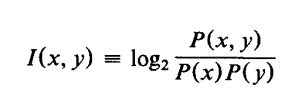

P(x) - prawdopodobieństwo wystąpienia słowa x (podzielone jego wystąpienia przez wszystkie)</p>

P(y) - prawdopodobieństwo wystąpienia słowa y (podzielone jego wystąpienia przez wszystkie)</p>

P(x,y) - prawdopodobieństwo współwystępowania słów x i y w oknie</p>

I(x,y) - MI




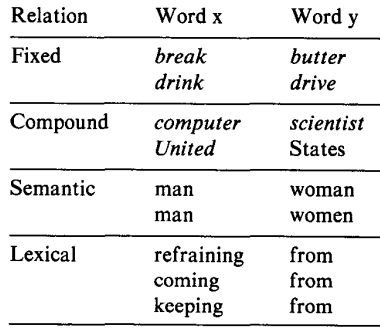

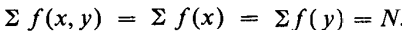

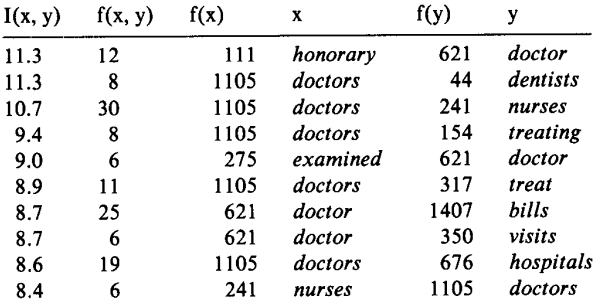

In [3]:
from clp3 import clp
import csv
import math
import re
from collections import Counter, defaultdict

def base(word):
    word = word.lower()
    word = word.replace('ō', 'o')
    word = word.replace('ū', 'u')
    word = re.sub(r'[^a-ząęśółżźćń]+', '', word)
    ids = clp.rec(word)
    if ids:
        return clp.bform(ids[0])
    else:
        return word

def clean(text):
    words = re.findall(r'[a-ząęśółżźćńA-ZĄĘŚÓŁŻŹĆŃ]+', text)
    base_forms = [base(word) for word in words]
    return [form for form in base_forms if form and len(form) > 1]

def load(folder_name="TXT"):
    texts = []
    for i in range(1,51):
        try:
            with open(f"{folder_name}/{i}.txt", "r", encoding="utf-8") as file:
                text = file.read()
                base_forms = clean(text)
                texts.append(base_forms)
        except FileNotFoundError:
             texts.append([])
    return texts

def prob_x(texts):
    # P(X) = (Liczba wystąpień X) / (Całkowita liczba słów w korpusie)
    total = 0 
    text_freq = defaultdict(int)
    for text in texts:
        for term in text:
            text_freq[term] += 1
            total += 1
    
    px_dict = {}
    if total > 0:
        for term, freq in text_freq.items():
            px_dict[term] = freq/total
    return px_dict

def prob_xy(texts):
    # P(X, Y) = (Liczba par (X, Y) obok siebie) / (Całkowita liczba słów w korpusie)
    total = 0
    co_freq = defaultdict(int)
    for text in texts:
        num_pairs_in_text = max(0, len(text) - 1)
        
        for i in range(len(text)-1):
            x = text[i]
            y = text[i+1]
            co_freq[(x,y)] += 1
        
        total += num_pairs_in_text
    
    pxy_dict = {}
    if total > 0:
        for (x,y), freq in co_freq.items():
            pxy_dict[(x,y)] = freq/total
    return pxy_dict

def MI(px_dict, pxy_dict):
    mi_dict = {}
    for (x,y), p_xy in pxy_dict.items():
        px = px_dict.get(x, 0)
        py = px_dict.get(y, 0)
        
        if px == 0 or py == 0 or p_xy == 0:
            continue
            
        div = p_xy / (px * py)
        mi = p_xy * math.log2(div) 
        mi_dict[(x,y)] = mi
    return mi_dict

texts = load()
pxd = prob_x(texts)
pxyd = prob_xy(texts)
MId = MI(pxd, pxyd)

sorted_mi = sorted(MId.items(), key=lambda x: x[1], reverse=True)

print("| Wynik MI | Para Słów |")
for i, ((x,y), score) in enumerate(sorted_mi[:20]): 
    print(f"| {score:.6f} | {x} - {y} |")

| Wynik MI | Para Słów |
| 0.010078 | system - kaucyjny |
| 0.006591 | las - vegas |
| 0.006030 | yerba - mate |
| 0.004296 | voice - of |
| 0.004296 | of - poland |
| 0.004204 | split - fiction |
| 0.004062 | znajdować - się |
| 0.003949 | liga - mistrz |
| 0.003694 | wiersz - polecenie |
| 0.003675 | być - to |
| 0.003673 | przede - wszyscy |
| 0.003647 | koło - naukowy |
| 0.003578 | grand - prix |
| 0.003506 | max - verstappen |
| 0.003483 | taki - jak |
| 0.003426 | the - voice |
| 0.003416 | wprowadzenie - system |
| 0.003320 | purpurowy - człowiek |
| 0.003296 | wolny - lektura |
| 0.003258 | hello - world |
